In [1]:
# import torch
# import torch.nn as nn
# import torch.optim as optim
# from torchvision import datasets, transforms
# from torch.utils.data import DataLoader
# import numpy as np
# import matplotlib.pyplot as plt
# import time

# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# print(f'Using device: {device}')

# # ── Dataset ──────────────────────────────────────────────────
# transform = transforms.Compose([
#     transforms.ToTensor(),
#     transforms.Normalize((0.1307,), (0.3081,))
# ])
# train_dataset = datasets.MNIST('./data', train=True,  download=True, transform=transform)
# test_dataset  = datasets.MNIST('./data', train=False, download=True, transform=transform)
# train_loader  = DataLoader(train_dataset, batch_size=64, shuffle=True)
# test_loader   = DataLoader(test_dataset,  batch_size=64, shuffle=False)
# print(f'Train: {len(train_dataset)}  Test: {len(test_dataset)}')


# # ── Option A: Row-Reshape [4×196] ────────────────────────────
# # 28×28 → [4×196]
# # L1: [4×196] · [196×64] → [4×64]   ReLU
# # L2: [4×64]  · [64×16]  → [4×16]
# # Pool: sum rows          → [16]  → first 10 = class scores
# #
# # Sysarray: 784 + 64 = 848 runs, 100% PE utilization
# class OptionA(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.fc1  = nn.Linear(196, 64)
#         self.fc2  = nn.Linear(64,  16)
#         self.relu = nn.ReLU()

#     def forward(self, x):
#         x = x.view(-1, 4, 196)        # [B, 4, 196]
#         x = self.relu(self.fc1(x))     # [B, 4, 64]
#         x = self.fc2(x)                # [B, 4, 16]
#         x = x.sum(dim=1)               # [B, 16]  row-sum pool
#         return x[:, :10]               # [B, 10]


# # ── Option C: Patch-Based [49 × 4×4] ─────────────────────────
# # 28×28 → 49 non-overlapping 4×4 patches → [49×16]
# # Patch stage: shared [16→16] linear (weight-stationary on SPAR)
# # FC stage:    [784→64→16]
# #
# # Sysarray: 49 + 3136 + 64 = 3249 runs
# # Note: FC stage still has vector input → A rows replicated there
# class OptionC(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.patch_fc = nn.Linear(16, 16)   # shared across 49 patches
#         self.fc1      = nn.Linear(784, 64)
#         self.fc2      = nn.Linear(64,  16)
#         self.relu     = nn.ReLU()

#     def forward(self, x):
#         B = x.shape[0]
#         x = x.unfold(2, 4, 4).unfold(3, 4, 4)   # [B, 1, 7, 7, 4, 4]
#         x = x.contiguous().view(B, 49, 16)        # [B, 49, 16]
#         x = self.relu(self.patch_fc(x))            # [B, 49, 16]
#         x = x.view(B, 784)                         # [B, 784]
#         x = self.relu(self.fc1(x))                 # [B, 64]
#         x = self.fc2(x)                            # [B, 16]
#         return x[:, :10]                           # [B, 10]


# # ── Training / Eval ───────────────────────────────────────────
# def train_epoch(model, loader, optimizer, criterion):
#     model.train()
#     total_loss, correct, total = 0, 0, 0
#     for data, target in loader:
#         data, target = data.to(device), target.to(device)
#         optimizer.zero_grad()
#         out  = model(data)
#         loss = criterion(out, target)
#         loss.backward()
#         optimizer.step()
#         total_loss += loss.item()
#         correct    += out.argmax(1).eq(target).sum().item()
#         total      += target.size(0)
#     return total_loss / len(loader), 100. * correct / total


# def evaluate(model, loader, criterion):
#     model.eval()
#     total_loss, correct, total = 0, 0, 0
#     with torch.no_grad():
#         for data, target in loader:
#             data, target = data.to(device), target.to(device)
#             out         = model(data)
#             total_loss += criterion(out, target).item()
#             correct    += out.argmax(1).eq(target).sum().item()
#             total      += target.size(0)
#     return total_loss / len(loader), 100. * correct / total


# def train_model(model, name, epochs=15, lr=1e-3):
#     optimizer = optim.Adam(model.parameters(), lr=lr)
#     criterion = nn.CrossEntropyLoss()
#     scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
#     history   = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
#     best_acc  = 0

#     print(f'\n{"="*55}')
#     print(f'  Training {name}')
#     print(f'{"="*55}')
#     t0 = time.time()

#     for epoch in range(1, epochs + 1):
#         tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
#         va_loss, va_acc = evaluate(model, test_loader, criterion)
#         scheduler.step()

#         history['train_loss'].append(tr_loss)
#         history['train_acc'].append(tr_acc)
#         history['val_loss'].append(va_loss)
#         history['val_acc'].append(va_acc)

#         if va_acc > best_acc:
#             best_acc = va_acc
#             torch.save(model.state_dict(), f'{name}_best.pt')

#         print(f'  Epoch {epoch:2d}/{epochs} | '
#               f'train loss {tr_loss:.4f} acc {tr_acc:.2f}% | '
#               f'val loss {va_loss:.4f} acc {va_acc:.2f}%')

#     print(f'\n  Best val acc : {best_acc:.2f}%')
#     print(f'  Time         : {time.time()-t0:.1f}s')
#     return history, best_acc


# # ── Run ───────────────────────────────────────────────────────
# EPOCHS    = 15
# model_a   = OptionA().to(device)
# model_c   = OptionC().to(device)
# params_a  = sum(p.numel() for p in model_a.parameters())
# params_c  = sum(p.numel() for p in model_c.parameters())

# history_a, best_a = train_model(model_a, 'OptionA', EPOCHS)
# history_c, best_c = train_model(model_c, 'OptionC', EPOCHS)


# # ── Summary table ─────────────────────────────────────────────
# print(f'\n{"="*55}')
# print(f'  SPAR COMPARISON SUMMARY')
# print(f'{"="*55}')
# print(f'  {"Metric":<32} {"Option A":>9} {"Option C":>9}')
# print(f'  {"-"*51}')
# print(f'  {"Best val accuracy":<32} {best_a:>8.2f}% {best_c:>8.2f}%')
# print(f'  {"Parameters":<32} {params_a:>9,} {params_c:>9,}')
# print(f'  {"Sysarray runs / inference":<32} {848:>9} {3249:>9}')
# print(f'  {"PE utilization":<32} {"100%":>9} {"mixed":>9}')
# print(f'  {"Weight memory (bytes)":<32} {params_a:>9,} {params_c:>9,}')
# winner = 'Option A' if best_a >= best_c else 'Option C'
# print(f'\n  Winner: {winner}  ({max(best_a, best_c):.2f}%)')


# # ── Per-class accuracy ────────────────────────────────────────
# def per_class_acc(model, loader):
#     model.eval()
#     cc = [0]*10;  ct = [0]*10
#     with torch.no_grad():
#         for data, target in loader:
#             data, target = data.to(device), target.to(device)
#             pred = model(data).argmax(1)
#             for t, p in zip(target, pred):
#                 ct[t.item()] += 1
#                 cc[t.item()] += (t == p).item()
#     return [100*cc[i]/ct[i] for i in range(10)]

# accs_a = per_class_acc(model_a, test_loader)
# accs_c = per_class_acc(model_c, test_loader)

# print(f'\n  {"Digit":<8} {"Option A":>9} {"Option C":>9}')
# print(f'  {"-"*28}')
# for i in range(10):
#     print(f'  {i:<8} {accs_a[i]:>8.1f}% {accs_c[i]:>8.1f}%')


# # ── Plots ─────────────────────────────────────────────────────
# epochs_range = range(1, EPOCHS + 1)
# fig, axes = plt.subplots(2, 2, figsize=(13, 9))
# fig.suptitle('SPAR: Option A vs Option C', fontsize=13, fontweight='bold')

# for ax, ya, yc, title in zip(
#     axes.flat,
#     [history_a['train_acc'], history_a['val_acc'],
#      history_a['train_loss'], history_a['val_loss']],
#     [history_c['train_acc'], history_c['val_acc'],
#      history_c['train_loss'], history_c['val_loss']],
#     ['Train Accuracy', 'Val Accuracy', 'Train Loss', 'Val Loss']
# ):
#     ax.plot(epochs_range, ya, 'b-o', label='Option A', markersize=4)
#     ax.plot(epochs_range, yc, 'r-s', label='Option C', markersize=4)
#     ax.set_title(title);  ax.set_xlabel('Epoch')
#     ax.legend();          ax.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.savefig('spar_comparison.png', dpi=150, bbox_inches='tight')
# plt.show()

# # Per-class bar chart
# fig, ax = plt.subplots(figsize=(11, 5))
# x = np.arange(10);  w = 0.35
# ax.bar(x - w/2, accs_a, w, label='Option A', color='steelblue', alpha=0.8)
# ax.bar(x + w/2, accs_c, w, label='Option C', color='tomato',    alpha=0.8)
# ax.set_xlabel('Digit');  ax.set_ylabel('Accuracy (%)')
# ax.set_title('Per-class Accuracy: Option A vs Option C')
# ax.set_xticks(x);  ax.set_ylim([80, 100])
# ax.legend();  ax.grid(True, alpha=0.3, axis='y')
# plt.tight_layout()
# plt.savefig('spar_perclass.png', dpi=150, bbox_inches='tight')
# plt.show()

Using device: cpu


100%|██████████| 9.91M/9.91M [00:00<00:00, 94.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 57.5MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 78.3MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.77MB/s]


Train: 60000  Test: 10000

SPARNet parameter count: 17,536

  Training SPARNet
Epoch  1/15 | train loss 0.5188 acc 84.59% | val loss 0.2154 acc 93.55%
Epoch  2/15 | train loss 0.1914 acc 94.27% | val loss 0.1531 acc 95.32%
Epoch  3/15 | train loss 0.1465 acc 95.69% | val loss 0.1321 acc 96.10%
Epoch  4/15 | train loss 0.1220 acc 96.39% | val loss 0.1202 acc 96.29%
Epoch  5/15 | train loss 0.1048 acc 96.90% | val loss 0.1064 acc 96.55%
Epoch  6/15 | train loss 0.0881 acc 97.39% | val loss 0.0986 acc 97.01%
Epoch  7/15 | train loss 0.0815 acc 97.61% | val loss 0.0934 acc 97.16%
Epoch  8/15 | train loss 0.0767 acc 97.73% | val loss 0.0909 acc 97.13%
Epoch  9/15 | train loss 0.0728 acc 97.83% | val loss 0.0906 acc 97.07%
Epoch 10/15 | train loss 0.0686 acc 97.99% | val loss 0.0878 acc 97.19%
Epoch 11/15 | train loss 0.0617 acc 98.18% | val loss 0.0858 acc 97.26%
Epoch 12/15 | train loss 0.0595 acc 98.26% | val loss 0.0844 acc 97.47%
Epoch 13/15 | train loss 0.0580 acc 98.30% | val loss 0.0

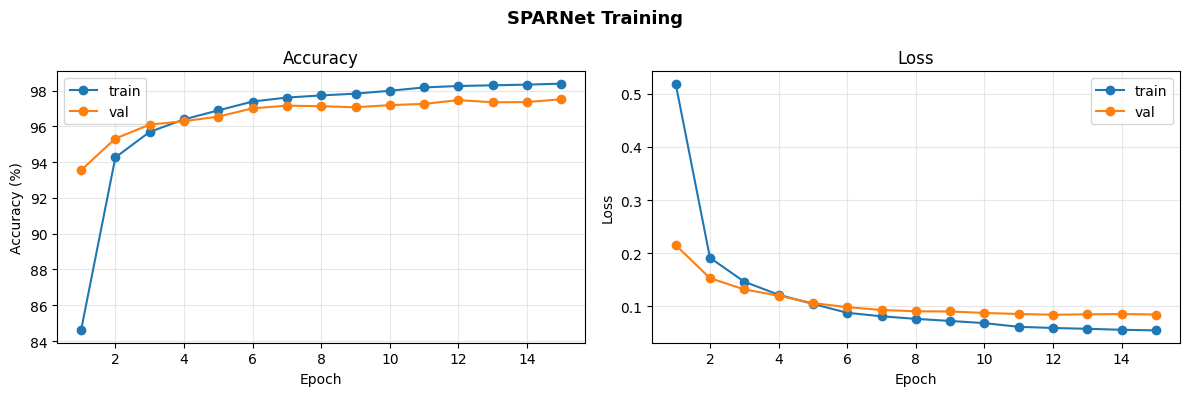


Final best accuracy: 97.52%


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f'Train: {len(train_dataset)}  Test: {len(test_dataset)}')


class SPARNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(196, 64, bias=True)
        self.fc2 = nn.Linear(64, 64, bias=True)

        # One 4×4 transform per slice
        self.W2 = nn.Parameter(torch.randn(16, 4, 4) * 0.1)
        self.b2 = nn.Parameter(torch.zeros(16, 4, 4))

        # Learned reduction weights
        self.reducer = nn.Parameter(torch.randn(16, 4, 4) * 0.1)

        self.relu = nn.ReLU()

    def forward(self, x):
        B = x.shape[0]

        # [B,1,28,28] -> [B,4,196]
        x = x.flatten(start_dim=1)
        x = x.reshape(B, 4, 196)

        # Stage 1
        x = self.relu(self.fc1(x))      # [B,4,64]

        # Stage 2
        x = self.relu(self.fc2(x))      # [B,4,64]

        # Split into 16 slices of 4×4
        x = x.reshape(B, 4, 16, 4)
        x = x.permute(0, 2, 1, 3)       # [B,16,4,4]

        # Apply class-specific 4×4 transforms
        S = x.reshape(B * 16, 4, 4)

        W2 = self.W2.unsqueeze(0).expand(B, -1, -1, -1)
        W2 = W2.reshape(B * 16, 4, 4)

        b2 = self.b2.unsqueeze(0).expand(B, -1, -1, -1)
        b2 = b2.reshape(B * 16, 4, 4)

        R = torch.bmm(S, W2) + b2
        R = self.relu(R)

        # Learned reduction
        R = R.reshape(B, 16, 4, 4)

        scores = (
            R * self.reducer.unsqueeze(0)
        ).sum(dim=(2, 3))

        scores = scores[:, :10]

        return scores


def train_epoch(model, loader, optimizer, criterion):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for data, target in loader:
        data = data.to(device)
        target = target.to(device)

        optimizer.zero_grad()

        out = model(data)
        loss = criterion(out, target)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += out.argmax(1).eq(target).sum().item()
        total += target.size(0)

    return total_loss / len(loader), 100.0 * correct / total


def evaluate(model, loader, criterion):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for data, target in loader:
            data = data.to(device)
            target = target.to(device)

            out = model(data)

            total_loss += criterion(out, target).item()
            correct += out.argmax(1).eq(target).sum().item()
            total += target.size(0)

    return total_loss / len(loader), 100.0 * correct / total


def train_model(model, name, epochs=15, lr=1e-3):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    scheduler = optim.lr_scheduler.StepLR(
        optimizer,
        step_size=5,
        gamma=0.5
    )

    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }

    best_acc = 0

    print(f'\n{"="*55}')
    print(f'  Training {name}')
    print(f'{"="*55}')

    start_time = time.time()

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch(
            model,
            train_loader,
            optimizer,
            criterion
        )

        va_loss, va_acc = evaluate(
            model,
            test_loader,
            criterion
        )

        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(va_loss)
        history['val_acc'].append(va_acc)

        if va_acc > best_acc:
            best_acc = va_acc
            torch.save(model.state_dict(), f'{name}_best.pt')

        print(
            f'Epoch {epoch:2d}/{epochs} | '
            f'train loss {tr_loss:.4f} acc {tr_acc:.2f}% | '
            f'val loss {va_loss:.4f} acc {va_acc:.2f}%'
        )

    elapsed = time.time() - start_time

    print(f'\nBest val acc : {best_acc:.2f}%')
    print(f'Time         : {elapsed:.1f}s')

    return history, best_acc


def per_class_acc(model, loader):
    model.eval()

    correct = [0] * 10
    total = [0] * 10

    with torch.no_grad():
        for data, target in loader:
            data = data.to(device)
            target = target.to(device)

            pred = model(data).argmax(1)

            for t, p in zip(target, pred):
                total[t.item()] += 1
                correct[t.item()] += (t == p).item()

    return [
        100.0 * correct[i] / total[i]
        for i in range(10)
    ]


model = SPARNet().to(device)

params = sum(
    p.numel()
    for p in model.parameters()
)

print(f'\nSPARNet parameter count: {params:,}')

history, best_acc = train_model(
    model,
    'SPARNet',
    epochs=15
)

accs = per_class_acc(model, test_loader)

print(f'\n{"Digit":<8} {"Accuracy":>9}')
print("-" * 20)

for i in range(10):
    print(f'{i:<8} {accs[i]:>8.1f}%')

epochs_range = range(
    1,
    len(history['train_acc']) + 1
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4)
)

fig.suptitle(
    'SPARNet Training',
    fontsize=13,
    fontweight='bold'
)

axes[0].plot(
    epochs_range,
    history['train_acc'],
    marker='o',
    label='train'
)

axes[0].plot(
    epochs_range,
    history['val_acc'],
    marker='o',
    label='val'
)

axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy (%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(
    epochs_range,
    history['train_loss'],
    marker='o',
    label='train'
)

axes[1].plot(
    epochs_range,
    history['val_loss'],
    marker='o',
    label='val'
)

axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sparnet.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nFinal best accuracy: {best_acc:.2f}%')

In [3]:
# ============================================================
# RANGE INSPECTION
# ============================================================

def inspect_ranges(model, loader):
    model.eval()

    fc1_min = float('inf')
    fc1_max = float('-inf')

    fc2_min = float('inf')
    fc2_max = float('-inf')

    w2_min = float('inf')
    w2_max = float('-inf')

    with torch.no_grad():
        for data, _ in loader:
            data = data.to(device)

            B = data.shape[0]

            x = data.flatten(start_dim=1)
            x = x.reshape(B, 4, 196)

            x = model.relu(model.fc1(x))

            fc1_min = min(fc1_min, x.min().item())
            fc1_max = max(fc1_max, x.max().item())

            x = model.relu(model.fc2(x))

            fc2_min = min(fc2_min, x.min().item())
            fc2_max = max(fc2_max, x.max().item())

            x = x.reshape(B, 4, 16, 4)
            x = x.permute(0, 2, 1, 3)

            S = x.reshape(B * 16, 4, 4)

            W2 = model.W2.unsqueeze(0).expand(B, -1, -1, -1)
            W2 = W2.reshape(B * 16, 4, 4)

            b2 = model.b2.unsqueeze(0).expand(B, -1, -1, -1)
            b2 = b2.reshape(B * 16, 4, 4)

            R = torch.bmm(S, W2) + b2
            R = model.relu(R)

            w2_min = min(w2_min, R.min().item())
            w2_max = max(w2_max, R.max().item())

    print("\nActivation Ranges")
    print("------------------------------")
    print(f"FC1 : [{fc1_min:.4f}, {fc1_max:.4f}]")
    print(f"FC2 : [{fc2_min:.4f}, {fc2_max:.4f}]")
    print(f"W2  : [{w2_min:.4f}, {w2_max:.4f}]")

# ============================================================
# QUANTIZATION HELPERS
# ============================================================

def quantize_tensor(t):
    max_abs = t.abs().max().item()

    if max_abs == 0:
        max_abs = 1.0

    scale = max_abs / 127.0

    q = torch.round(t / scale)
    q = torch.clamp(q, -127, 127)

    return q.to(torch.int8), scale


def build_quantized_model(model):
    q = {}

    q["fc1_w"], q["fc1_w_scale"] = quantize_tensor(
        model.fc1.weight.data.cpu()
    )

    q["fc1_b"], q["fc1_b_scale"] = quantize_tensor(
        model.fc1.bias.data.cpu()
    )

    q["fc2_w"], q["fc2_w_scale"] = quantize_tensor(
        model.fc2.weight.data.cpu()
    )

    q["fc2_b"], q["fc2_b_scale"] = quantize_tensor(
        model.fc2.bias.data.cpu()
    )

    q["W2"], q["W2_scale"] = quantize_tensor(
        model.W2.data.cpu()
    )

    q["b2"], q["b2_scale"] = quantize_tensor(
        model.b2.data.cpu()
    )

    q["reducer"], q["reducer_scale"] = quantize_tensor(
        model.reducer.data.cpu()
    )

    return q


def requantize(x, shift):
    x = x >> shift
    x = torch.clamp(x, -128, 127)
    return x.to(torch.int8)

# ============================================================
# INT8 INFERENCE
# ============================================================

def int8_forward(
    model_q,
    images,
    fc1_shift=15,
    fc2_shift=13,
    w2_shift=9
):
    B = images.shape[0]

    x = images.flatten(start_dim=1)

    # input quantization
    x = torch.round(x * 32)
    x = torch.clamp(x, -128, 127)
    x = x.to(torch.int8)

    x = x.reshape(B, 4, 196)

    # =====================================================
    # FC1
    # =====================================================

    fc1_w = model_q["fc1_w"].to(torch.int32)
    fc1_b = model_q["fc1_b"].to(torch.int32)

    x = x.to(torch.int32)

    x = torch.matmul(
        x,
        fc1_w.t()
    )

    x = x + fc1_b

    x = torch.relu(x)

    x = requantize(
        x,
        fc1_shift
    )

    # =====================================================
    # FC2
    # =====================================================

    fc2_w = model_q["fc2_w"].to(torch.int32)
    fc2_b = model_q["fc2_b"].to(torch.int32)

    x = x.to(torch.int32)

    x = torch.matmul(
        x,
        fc2_w.t()
    )

    x = x + fc2_b

    x = torch.relu(x)

    x = requantize(
        x,
        fc2_shift
    )

    # =====================================================
    # 16 × 4×4 SLICES
    # =====================================================

    x = x.reshape(B, 4, 16, 4)
    x = x.permute(0, 2, 1, 3)

    S = x.reshape(B * 16, 4, 4)

    W2 = model_q["W2"].to(torch.int32)
    W2 = W2.unsqueeze(0).expand(B, -1, -1, -1)
    W2 = W2.reshape(B * 16, 4, 4)

    b2 = model_q["b2"].to(torch.int32)
    b2 = b2.unsqueeze(0).expand(B, -1, -1, -1)
    b2 = b2.reshape(B * 16, 4, 4)

    R = torch.bmm(
        S.to(torch.int32),
        W2
    )

    R = R + b2

    R = torch.relu(R)

    R = requantize(
        R,
        w2_shift
    )

    # =====================================================
    # LEARNED REDUCER
    # =====================================================

    R = R.reshape(B, 16, 4, 4)

    reducer = model_q["reducer"].to(torch.int32)

    scores = (
        R.to(torch.int32)
        * reducer.unsqueeze(0)
    ).sum(dim=(2, 3))

    scores = scores[:, :10]

    return scores

# ============================================================
# INT8 EVALUATION
# ============================================================

def evaluate_int8(
    model_q,
    loader,
    fc1_shift,
    fc2_shift,
    w2_shift
):
    correct = 0
    total = 0

    with torch.no_grad():
        for data, target in loader:

            scores = int8_forward(
                model_q,
                data,
                fc1_shift,
                fc2_shift,
                w2_shift
            )

            pred = scores.argmax(1)

            correct += pred.eq(target).sum().item()
            total += target.size(0)

    return 100.0 * correct / total

# ============================================================
# RUN QUANTIZATION EXPERIMENT
# ============================================================

inspect_ranges(model, test_loader)

qmodel = build_quantized_model(model)

print("\nSearching shifts...")
print("--------------------------------")

best_acc = 0
best_cfg = None

for fc1_shift in range(10, 11):

    for fc2_shift in range(7, 9):

        for w2_shift in range(6, 11):

            acc = evaluate_int8(
                qmodel,
                test_loader,
                fc1_shift,
                fc2_shift,
                w2_shift
            )

            if acc > best_acc:
                best_acc = acc
                best_cfg = (
                    fc1_shift,
                    fc2_shift,
                    w2_shift
                )

            print(
                f"fc1={fc1_shift:2d} "
                f"fc2={fc2_shift:2d} "
                f"w2={w2_shift:2d} "
                f"acc={acc:.2f}%"
            )

print("\nBest configuration")
print("--------------------------------")
print(
    f"fc1_shift={best_cfg[0]}, "
    f"fc2_shift={best_cfg[1]}, "
    f"w2_shift={best_cfg[2]}"
)
print(
    f"accuracy={best_acc:.2f}%"
)


Activation Ranges
------------------------------
FC1 : [0.0000, 35.3688]
FC2 : [0.0000, 77.0123]
W2  : [0.0000, 58.2852]

Searching shifts...
--------------------------------
fc1=10 fc2= 7 w2= 6 acc=91.44%
fc1=10 fc2= 7 w2= 7 acc=96.10%
fc1=10 fc2= 7 w2= 8 acc=96.45%
fc1=10 fc2= 7 w2= 9 acc=96.47%
fc1=10 fc2= 7 w2=10 acc=96.32%
fc1=10 fc2= 8 w2= 6 acc=96.82%
fc1=10 fc2= 8 w2= 7 acc=97.35%
fc1=10 fc2= 8 w2= 8 acc=97.32%
fc1=10 fc2= 8 w2= 9 acc=97.18%
fc1=10 fc2= 8 w2=10 acc=96.63%

Best configuration
--------------------------------
fc1_shift=10, fc2_shift=8, w2_shift=7
accuracy=97.35%


In [4]:
def save_mem_file(tensor, filename):
    tensor = tensor.cpu().numpy().astype(np.int8)

    with open(filename, "w") as f:
        for value in tensor.flatten():
            f.write(f"{int(value)}\n")

    print(f"Saved {filename}")
def save_hex_mem(tensor, filename):
    tensor = tensor.cpu().numpy().astype(np.int8)

    with open(filename, "w") as f:
        for value in tensor.flatten():

            value = np.uint8(value)

            f.write(f"{value:02X}\n")

    print(f"Saved {filename}")


# Build quantized model
qmodel = build_quantized_model(model)

# Export files
save_mem_file(
    qmodel["fc1_w"],
    "fc1_weights.mem"
)

save_mem_file(
    qmodel["fc2_w"],
    "fc2_weights.mem"
)

save_mem_file(
    qmodel["W2"],
    "w2_weights.mem"
)

save_mem_file(
    qmodel["reducer"],
    "reducer.mem"
)

save_hex_mem(qmodel["fc1_b"], "fc1_bias.mem")
save_hex_mem(qmodel["fc2_b"], "fc2_bias.mem")
save_hex_mem(qmodel["b2"], "w2_bias.mem")

Saved fc1_weights.mem
Saved fc2_weights.mem
Saved w2_weights.mem
Saved reducer.mem
Saved fc1_bias.mem
Saved fc2_bias.mem
Saved w2_bias.mem


In [6]:
# ============================================================
# ACCELERATOR MEMORY EXPORT (byte-addressed, 16 bytes per block)
# ============================================================

def to_u8(v):
    """int8 (-128..127) -> unsigned byte representation"""
    return int(v) & 0xFF

def split_cols_row_major(matrix, group_size=4):
    rows, cols = matrix.shape
    assert cols % group_size == 0
    n_chunks = cols // group_size
    flat = []
    for c in range(n_chunks):
        chunk = matrix[:, c*group_size:(c+1)*group_size]
        flat.extend(chunk.flatten().tolist())
    return flat

def flatten_slices_row_major(tensor3d):
    return tensor3d.reshape(-1, 4).flatten().tolist()

def flatten_bias_words(bias_1d):
    return list(bias_1d.flatten().tolist())


# ------------------------------------------------------------
# Build flat byte stream in memory order
# ------------------------------------------------------------

qmodel = build_quantized_model(model)

fc1_w_T = qmodel["fc1_w"].cpu().numpy().T
fc2_w_T = qmodel["fc2_w"].cpu().numpy().T
fc1_b   = qmodel["fc1_b"].cpu().numpy()
fc2_b   = qmodel["fc2_b"].cpu().numpy()
W2      = qmodel["W2"].cpu().numpy()
b2      = qmodel["b2"].cpu().numpy()
reducer = qmodel["reducer"].cpu().numpy()

sections = []

sections.append(("fc1_weight", split_cols_row_major(fc1_w_T, group_size=4)))
sections.append(("fc1_bias",   flatten_bias_words(fc1_b)))
sections.append(("fc2_weight", split_cols_row_major(fc2_w_T, group_size=4)))
sections.append(("fc2_bias",   flatten_bias_words(fc2_b)))
sections.append(("W2",         flatten_slices_row_major(W2)))
sections.append(("b2",         flatten_slices_row_major(b2)))
sections.append(("reducer",    flatten_slices_row_major(reducer)))

section_offsets = []  # (name, start_addr, end_addr, num_bytes)

START_ADDR = 0x00000010
all_bytes = [0x00] * START_ADDR   # reserved zero region 0x0 - 0xF

addr = START_ADDR
for name, values in sections:
    start = addr
    for v in values:
        all_bytes.append(to_u8(v))
        addr += 1
    section_offsets.append((name, start, addr - 1, addr - start))

# ------------------------------------------------------------
# Write out in "// 0xADDRESS" + 16 bytes per block format
# ------------------------------------------------------------

def write_mem_dump(byte_list, filename, bytes_per_block=16):
    with open(filename, "w") as f:
        for i in range(0, len(byte_list), bytes_per_block):
            block_addr = i
            f.write(f"// 0x{block_addr:08X}\n")
            block = byte_list[i:i + bytes_per_block]
            for b in block:
                f.write(f"{b:02X}\n")
    print(f"Saved {filename} : {len(byte_list)} bytes "
          f"({len(byte_list) // bytes_per_block} blocks of {bytes_per_block})")

write_mem_dump(all_bytes, "nova_memory.mem")

# ------------------------------------------------------------
# Section address map for reference
# ------------------------------------------------------------

print(f"\n{'Section':15s} {'Start':>12s} {'End':>12s} {'#Bytes':>8s}")
print("-" * 55)
for name, s, e, n in section_offsets:
    print(f"{name:15s}   0x{s:08X}   0x{e:08X}   {n:6d}")

Saved nova_memory.mem : 17552 bytes (1097 blocks of 16)

Section                Start          End   #Bytes
-------------------------------------------------------
fc1_weight        0x00000010   0x0000310F    12544
fc1_bias          0x00003110   0x0000314F       64
fc2_weight        0x00003150   0x0000414F     4096
fc2_bias          0x00004150   0x0000418F       64
W2                0x00004190   0x0000428F      256
b2                0x00004290   0x0000438F      256
reducer           0x00004390   0x0000448F      256
